# Clustering Olivetti Faces

## Setup

In [34]:
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [1]:
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [13]:
X = data.data
y = data.target

In [14]:
print(len(X), len(X[0]))
print(len(y))

400 4096
400


In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(X, y))
X_train_valid = X[train_valid_idx]
y_train_valid = y[train_valid_idx]
X_test = X[test_idx]
y_test = y[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=42)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X[train_idx]
y_train = y[train_idx]
X_valid = X[valid_idx]
y_valid = y[valid_idx]

In [17]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(280, 4096) (280,)
(80, 4096) (80,)
(40, 4096) (40,)


## Use PCA to speed up training

In [21]:
from sklearn.decomposition import PCA
pca = PCA(0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(198)

## Clustering using k-means

In [71]:
from sklearn.cluster import KMeans

k_range = range(5, 150, 5)
kmeans_per_k = []

for k in k_range:
  print("k=", k)
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_train_pca)
  kmeans_per_k.append(kmeans)

k= 5
k= 10
k= 15
k= 20
k= 25
k= 30
k= 35
k= 40
k= 45
k= 50
k= 55
k= 60
k= 65
k= 70
k= 75
k= 80
k= 85
k= 90
k= 95
k= 100
k= 105
k= 110
k= 115
k= 120
k= 125
k= 130
k= 135
k= 140
k= 145


In [72]:
kmeans_per_k[0].labels_

array([0, 1, 0, 3, 1, 3, 3, 3, 1, 4, 1, 2, 2, 4, 2, 1, 3, 2, 2, 2, 3, 1,
       1, 4, 0, 4, 1, 0, 3, 1, 1, 1, 1, 1, 2, 3, 4, 2, 1, 3, 2, 1, 1, 1,
       2, 1, 3, 1, 1, 2, 3, 1, 0, 1, 4, 1, 4, 4, 4, 0, 1, 0, 0, 1, 2, 4,
       4, 0, 0, 1, 1, 1, 3, 2, 1, 4, 2, 2, 2, 1, 0, 1, 0, 4, 0, 1, 2, 3,
       0, 2, 1, 4, 2, 4, 4, 4, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 2, 0, 1, 1,
       0, 1, 2, 1, 1, 4, 3, 0, 0, 1, 3, 4, 0, 4, 0, 1, 1, 1, 1, 3, 0, 0,
       4, 2, 2, 1, 3, 3, 4, 3, 2, 4, 2, 1, 3, 4, 1, 0, 1, 1, 2, 0, 2, 3,
       1, 0, 1, 3, 4, 0, 3, 3, 3, 1, 4, 3, 3, 1, 3, 1, 2, 3, 1, 1, 2, 4,
       0, 1, 1, 1, 4, 1, 1, 4, 0, 3, 2, 2, 1, 1, 2, 2, 0, 0, 4, 4, 0, 1,
       3, 3, 4, 0, 4, 0, 1, 3, 1, 2, 3, 3, 3, 1, 1, 1, 0, 2, 1, 4, 1, 0,
       4, 3, 0, 1, 1, 1, 0, 2, 2, 1, 1, 4, 2, 4, 3, 3, 1, 3, 0, 1, 1, 2,
       1, 1, 2, 3, 1, 1, 4, 0, 0, 2, 4, 3, 1, 4, 1, 1, 3, 2, 4, 3, 1, 1,
       1, 1, 1, 4, 3, 3, 2, 1, 2, 1, 3, 2, 4, 2, 1, 1], dtype=int32)

In [73]:
# use silhouette score to choose the best k
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_) for model in kmeans_per_k]

In [76]:
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index]
best_score = silhouette_scores[best_index]

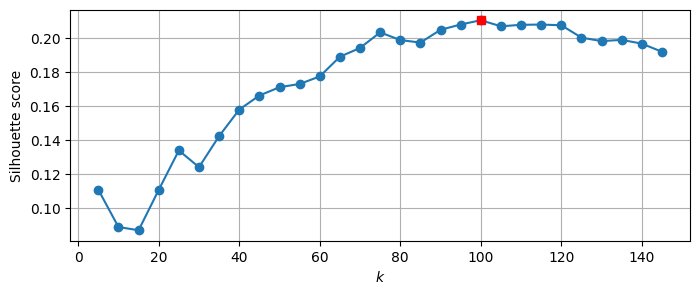

In [77]:
plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "o-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [78]:
best_k

100

It looks like the best number of clusters is quite high, at 120. You might have expected it to be 40, since there are 40 different people on the pictures. However, the same person may look quite different on different pictures (e.g., with or without glasses, or simply shifted left or right).

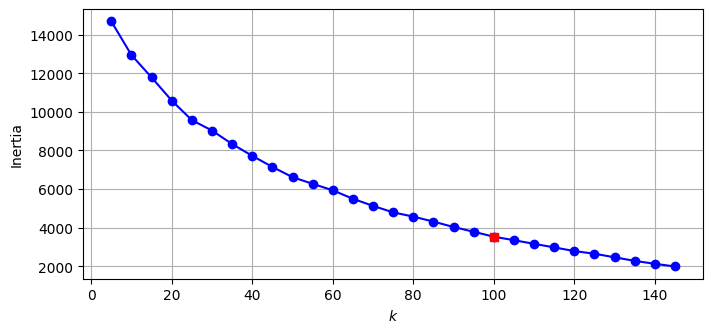

In [79]:
inertias = [model.inertia_ for model in kmeans_per_k]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

The optimal number of clusters is not clear on this inertia diagram, as there is no obvious elbow, so let's stick with k=95

In [80]:
best_model = kmeans_per_k[best_index]

In [81]:
np.unique(best_model.labels_)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99],
      dtype=int32)

Cluster  0


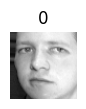

Cluster  1


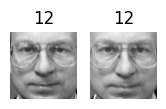

Cluster  2


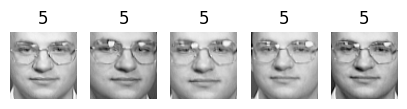

Cluster  3


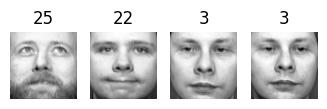

Cluster  4


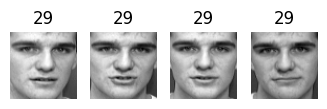

Cluster  5


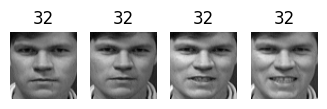

Cluster  6


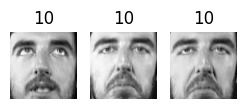

Cluster  7


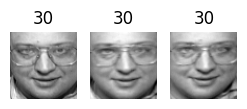

Cluster  8


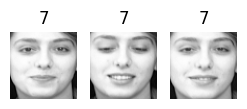

Cluster  9


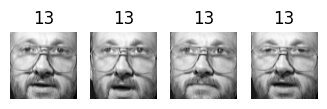

Cluster  10


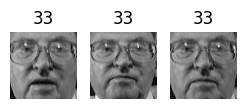

Cluster  11


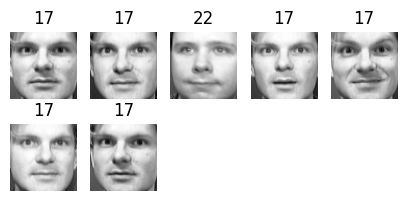

Cluster  12


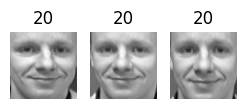

Cluster  13


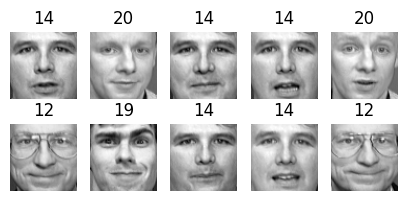

Cluster  14


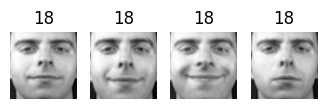

Cluster  15


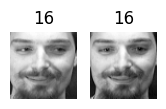

Cluster  16


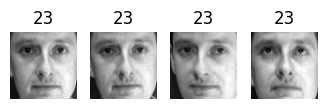

Cluster  17


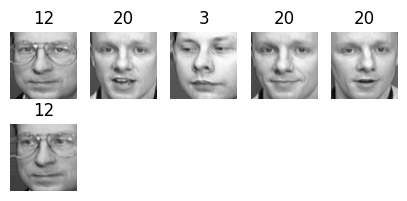

Cluster  18


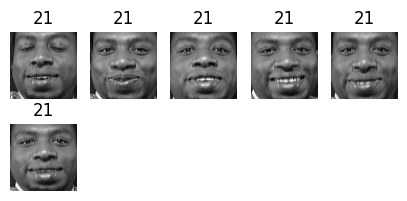

Cluster  19


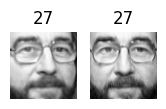

Cluster  20


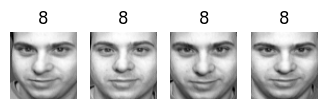

Cluster  21


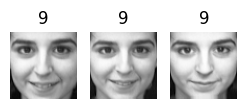

Cluster  22


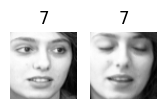

Cluster  23


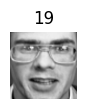

Cluster  24


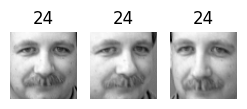

Cluster  25


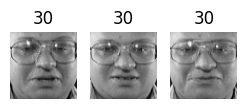

Cluster  26


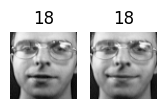

Cluster  27


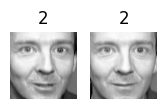

Cluster  28


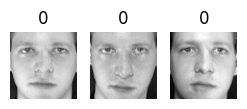

Cluster  29


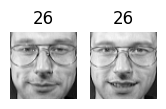

Cluster  30


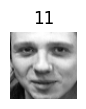

Cluster  31


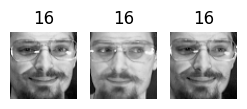

Cluster  32


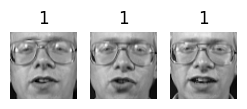

Cluster  33


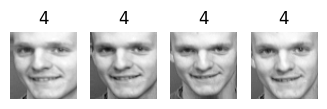

Cluster  34


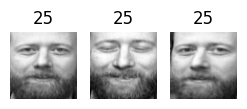

Cluster  35


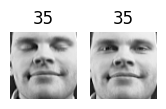

Cluster  36


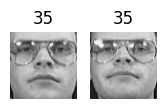

Cluster  37


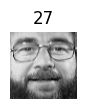

Cluster  38


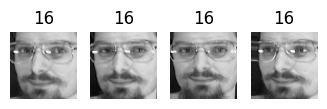

Cluster  39


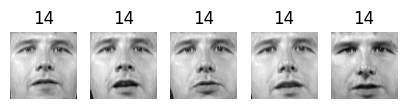

Cluster  40


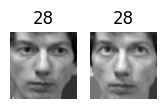

Cluster  41


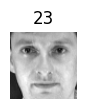

Cluster  42


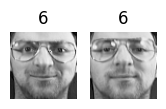

Cluster  43


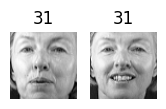

Cluster  44


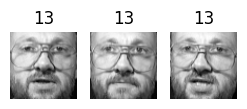

Cluster  45


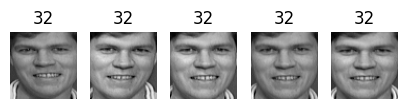

Cluster  46


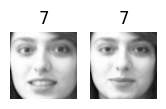

Cluster  47


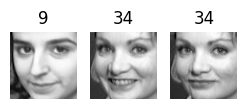

Cluster  48


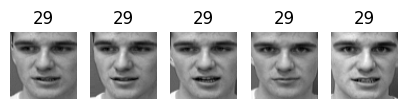

Cluster  49


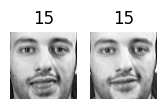

Cluster  50


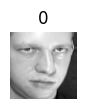

Cluster  51


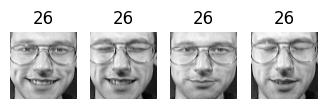

Cluster  52


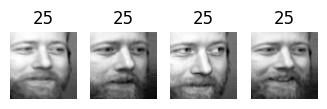

Cluster  53


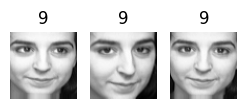

Cluster  54


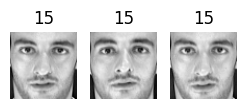

Cluster  55


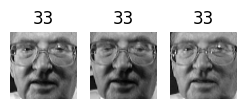

Cluster  56


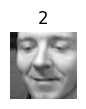

Cluster  57


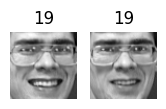

Cluster  58


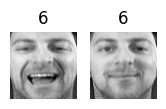

Cluster  59


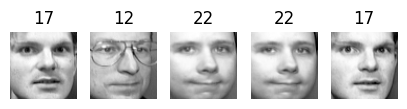

Cluster  60


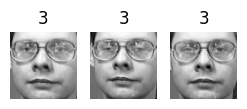

Cluster  61


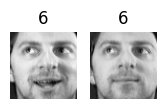

Cluster  62


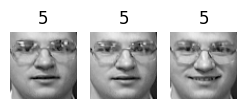

Cluster  63


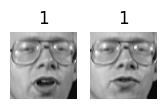

Cluster  64


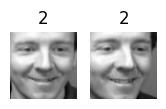

Cluster  65


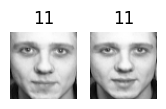

Cluster  66


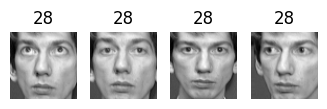

Cluster  67


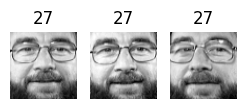

Cluster  68


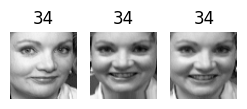

Cluster  69


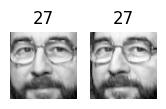

Cluster  70


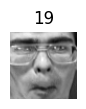

Cluster  71


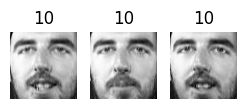

Cluster  72


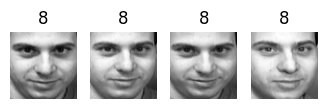

Cluster  73


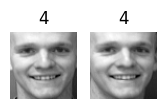

Cluster  74


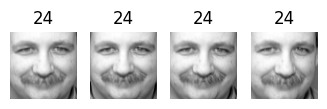

Cluster  75


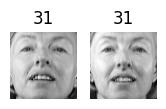

Cluster  76


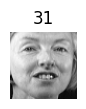

Cluster  77


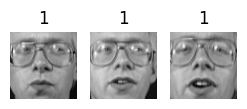

Cluster  78


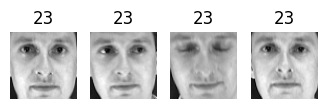

Cluster  79


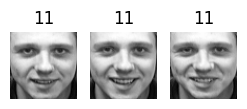

Cluster  80


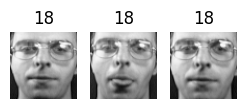

Cluster  81


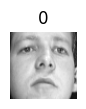

Cluster  82


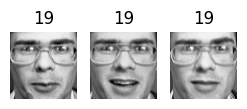

Cluster  83


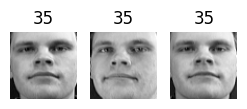

Cluster  84


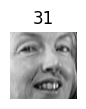

Cluster  85


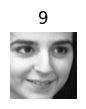

Cluster  86


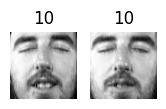

Cluster  87


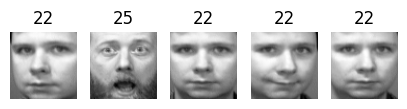

Cluster  88


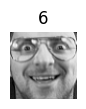

Cluster  89


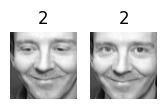

Cluster  90


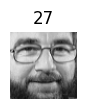

Cluster  91


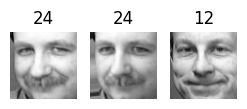

Cluster  92


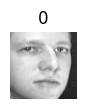

Cluster  93


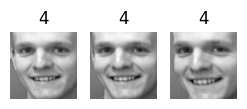

Cluster  94


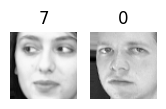

Cluster  95


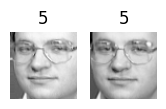

Cluster  96


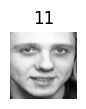

Cluster  97


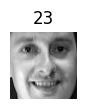

Cluster  98


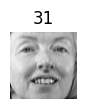

Cluster  99


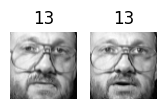

In [82]:
# visualize clusters
def plot_faces(faces, labels, n_cols=5):
  faces = faces.reshape(-1, 64, 64)
  n_rows = (len(faces) - 1) // n_cols + 1
  plt.figure(figsize=(n_cols, n_rows * 1.1))
  for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
  plt.show()


for cluster_id in np.unique(best_model.labels_):
  print("Cluster ", cluster_id)
  in_cluster = best_model.labels_==cluster_id
  faces = X_train[in_cluster]
  labels = y_train[in_cluster]
  plot_faces(faces, labels)

train a classifier

In [83]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train)
clf.score(X_valid_pca, y_valid)

0.8875

use kmeans as dimensionality reduction tool

In [84]:
best_model.transform(X_train_pca)

array([[ 9.491468 ,  9.194904 , 12.19767  , ..., 13.759587 , 13.791152 ,
        12.350604 ],
       [16.50853  ,  7.9993925, 15.896401 , ..., 11.266525 , 12.9124   ,
        10.304987 ],
       [12.551828 , 10.720857 , 15.27959  , ..., 13.453113 , 13.941267 ,
        13.249078 ],
       ...,
       [13.371421 , 12.573175 , 10.885841 , ..., 14.718393 , 13.828248 ,
        15.153916 ],
       [15.877245 ,  7.7081065, 13.090671 , ..., 10.742445 , 10.875777 ,
        11.364034 ],
       [13.904158 ,  8.279036 , 11.289322 , ..., 11.3677025, 11.234241 ,
         9.62388  ]], dtype=float32)

In [85]:
X_train_reduced = best_model.transform(X_train_pca)
X_valid_reduced = best_model.transform(X_valid_pca)
X_test_reduced = best_model.transform(X_test_pca)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reduced, y_train)

clf.score(X_valid_reduced, y_valid)

0.6

We could use a GridSearchCV like we did earlier in this notebook, but since we already have a validation set, we don't need K-fold cross-validation, and we're only exploring a single hyperparameter, so it's simpler to just run a loop manually:

In [87]:
from sklearn.pipeline import make_pipeline

for n_clusters in k_range:
  pipeline = make_pipeline(
      KMeans(n_clusters=n_clusters, n_init=10, random_state=42),
      RandomForestClassifier(n_estimators=150, random_state=42)
  )
  pipeline.fit(X_train_pca, y_train)
  print(n_clusters, pipeline.score(X_valid_pca, y_valid))

5 0.3375
10 0.5
15 0.5625
20 0.575
25 0.625
30 0.6125
35 0.65
40 0.625
45 0.6875
50 0.6375
55 0.6625
60 0.6375
65 0.625
70 0.675
75 0.65
80 0.625
85 0.65
90 0.6
95 0.6875
100 0.6
105 0.6375
110 0.6375
115 0.6625
120 0.6625
125 0.6625
130 0.6625
135 0.65
140 0.6875
145 0.7


What if you append the features from the reduced set to the original features (again, searching for the best number of clusters)?

In [88]:
X_train_extended = np.c_[X_train_pca, X_train_reduced]
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]
X_test_extended = np.c_[X_test_pca, X_test_reduced]

In [89]:
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_extended, y_train)
clf.score(X_valid_extended, y_valid)

0.7125

## Clustering using a Gaussian Mixture

In [90]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=42)
y_pred = gm.fit_predict(X_train_pca)

Use the model to generate some new faces (using the sample() method), and visualize them (if you used PCA, you will need to use its inverse_transform() method).

In [91]:
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)

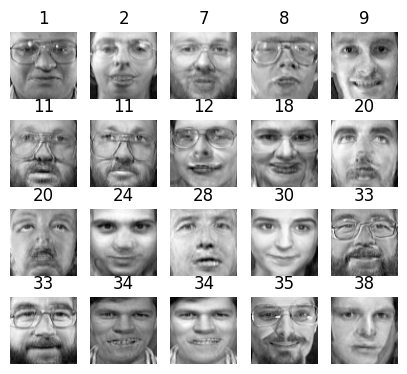

In [92]:
plot_faces(gen_faces, y_gen_faces)